# Part1 获取数据

In [4]:
import pandas as pd 
df1 = pd.read_excel('商品销售数据.xlsx',sheet_name = '信息表')
df1.head()

,商品大类,商品小类,商品名称,商品编号,商品销售价
0,运动上装,背心,瑜伽背心,bx001,48
1,运动上装,背心,跑步运动背心,bx002,39
2,运动上装,背心,纯色简约背心,bx003,36
3,运动上装,背心,轻薄透气背心,bx004,49
4,运动上装,背心,修身运动背心,bx005,50


In [5]:
df2 =pd.read_excel('商品销售数据.xlsx',sheet_name = '销售数据表')
df2.head(20)

,订单日期,订单编号,商品编号,订单数量
0,2022-01-01,HS2022000001,fd003,26
1,2022-01-01,HS2022000002,fd004,28
2,2022-01-01,HS2022000003,sh001,20
3,2022-01-01,HS2022000004,sh003,35
4,2022-01-01,HS2022000005,bx002,60
5,2022-01-01,HS2022000006,dx001,99
6,2022-01-02,HS2022000007,cx001,90
7,2022-01-02,HS2022000008,dk003,100
8,2022-01-02,HS2022000009,zck004,102
9,2022-01-02,HS2022000010,fd002,55


In [7]:
df = pd.merge(df1, df2, on='商品编号', how = 'right')
df.head()

,商品大类,商品小类,商品名称,商品编号,商品销售价,订单日期,订单编号,订单数量
0,运动配饰,发带,纯色弹力发带,fd003,12.0,2022-01-01,HS2022000001,26
1,运动配饰,发带,糖果色弹力发带,fd004,16.0,2022-01-01,HS2022000002,28
2,运动配饰,手环,篮球运动手环,sh001,8.0,2022-01-01,HS2022000003,20
3,运动配饰,手环,小清新硅胶手环,sh003,6.0,2022-01-01,HS2022000004,35
4,运动上装,背心,跑步运动背心,bx002,39.0,2022-01-01,HS2022000005,60


# Part2 分类统计数据


In [8]:
df['销售金额'] = df['商品销售价'] * df['订单数量']

In [10]:
# 如果订单日期还不是 datetime 类型，先转换
df['订单日期'] = pd.to_datetime(df['订单日期'])  

# 提取月份，新增列“月份”
df['月份'] = df['订单日期'].dt.month

In [14]:
# 按月份分组，统计每月销售金额总和
monthly_sales = df.groupby('月份')['销售金额'].sum()

# 打印结果（或根据需求格式化输出）
print(monthly_sales)

# （可选）重置索引，让结果更美观（变成 DataFrame 格式）
monthly_sales_df = monthly_sales.reset_index()
print(monthly_sales_df)

月份
1     344878.0
2     375111.0
3     431575.0
4     408359.0
5     463358.0
6     424416.0
7     490090.0
8     468356.0
9     433489.0
10    485727.0
11    484643.0
12    470306.0
Name: 销售金额, dtype: float64
    月份      销售金额
0    1  344878.0
1    2  375111.0
2    3  431575.0
3    4  408359.0
4    5  463358.0
5    6  424416.0
6    7  490090.0
7    8  468356.0
8    9  433489.0
9   10  485727.0
10  11  484643.0
11  12  470306.0


In [15]:
df.head()

,商品大类,商品小类,商品名称,商品编号,商品销售价,订单日期,订单编号,订单数量,销售金额,月份
0,运动配饰,发带,纯色弹力发带,fd003,12.0,2022-01-01,HS2022000001,26,312.0,1
1,运动配饰,发带,糖果色弹力发带,fd004,16.0,2022-01-01,HS2022000002,28,448.0,1
2,运动配饰,手环,篮球运动手环,sh001,8.0,2022-01-01,HS2022000003,20,160.0,1
3,运动配饰,手环,小清新硅胶手环,sh003,6.0,2022-01-01,HS2022000004,35,210.0,1
4,运动上装,背心,跑步运动背心,bx002,39.0,2022-01-01,HS2022000005,60,2340.0,1


# Part3 分析商品每月销售变化趋势



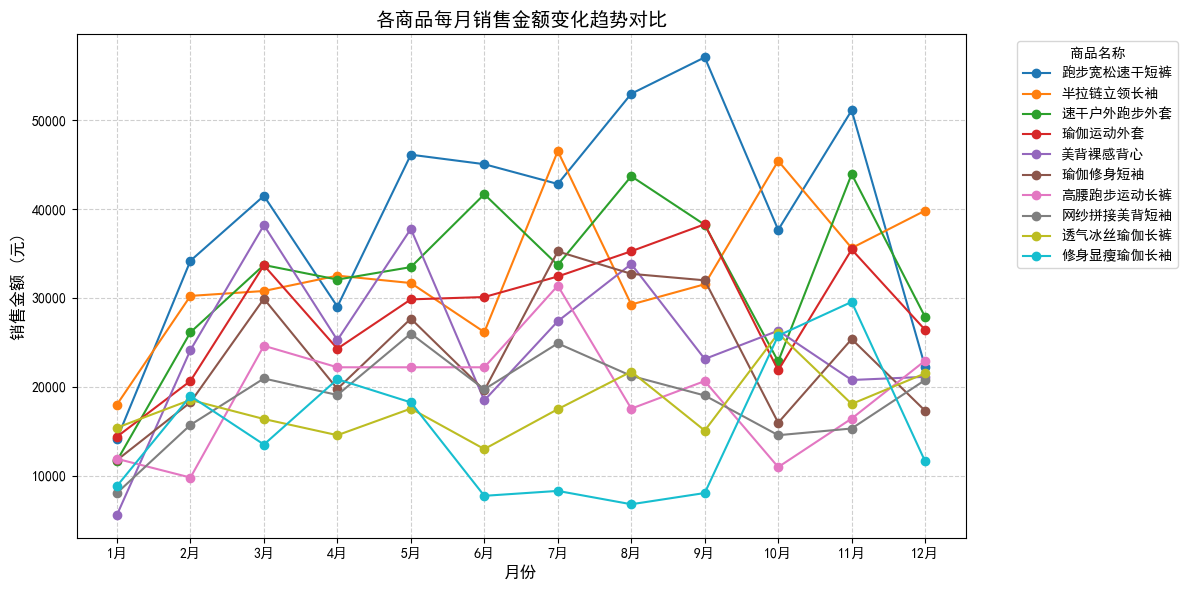

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 按【商品名称】和【月份】分组，计算每个商品每月的销售总额
product_monthly_sales = df.groupby(['商品名称', '月份'])['销售金额'].sum().reset_index()

# 2. 提取所有唯一的月份（确保是1-12月完整）
months = list(range(1, 13))  # 固定为1-12月
products = product_monthly_sales['商品名称'].unique()

# 3. 绘制折线图
plt.figure(figsize=(12, 6))

# 只取销售额前10的商品
top_products = product_monthly_sales.groupby('商品名称')['销售金额'].sum().nlargest(10).index
product_monthly_sales = product_monthly_sales[product_monthly_sales['商品名称'].isin(top_products)]
products = top_products

for product in products:
    # 筛选当前商品的数据
    product_data = product_monthly_sales[product_monthly_sales['商品名称'] == product]
    
    # 关键修复：将月份设为索引，reindex 补全缺失月份（用0填充）
    product_data_full = product_data.set_index('月份').reindex(months, fill_value=0).reset_index()
    
    # 绘制折线
    plt.plot(
        product_data_full['月份'], 
        product_data_full['销售金额'], 
        marker='o', 
        linestyle='-', 
        label=product
    )

# 4. 设置图表
plt.title('各商品每月销售金额变化趋势对比', fontsize=14)
plt.xlabel('月份', fontsize=12)
plt.ylabel('销售金额 (元)', fontsize=12)
plt.xticks(months, [f'{m}月' for m in months])
plt.legend(title='商品名称', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Part4 分析商品

In [19]:
# 按【月份】和【商品大类】分组，汇总销售金额
category_monthly_sales = df.groupby(['月份', '商品大类'])['销售金额'].sum().reset_index()

In [20]:
# 查看分组后的数据（每个月份+商品大类的销售总额）
print(category_monthly_sales)

    月份  商品大类      销售金额
0    1  运动上装  192671.0
1    1  运动下装  107039.0
2    1  运动配饰   45168.0
3    2  运动上装  250799.0
4    2  运动下装   96170.0
5    2  运动配饰   28142.0
6    3  运动上装  274574.0
7    3  运动下装  118169.0
8    3  运动配饰   38832.0
9    4  运动上装  257393.0
10   4  运动下装  113111.0
11   4  运动配饰   37855.0
12   5  运动上装  288187.0
13   5  运动下装  132609.0
14   5  运动配饰   42562.0
15   6  运动上装  260644.0
16   6  运动下装  115136.0
17   6  运动配饰   48636.0
18   7  运动上装  308293.0
19   7  运动下装  136504.0
20   7  运动配饰   45293.0
21   8  运动上装  281502.0
22   8  运动下装  131772.0
23   8  运动配饰   55082.0
24   9  运动上装  255780.0
25   9  运动下装  126671.0
26   9  运动配饰   51038.0
27  10  运动上装  306971.0
28  10  运动下装  135827.0
29  10  运动配饰   42929.0
30  11  运动上装  309149.0
31  11  运动下装  134972.0
32  11  运动配饰   40522.0
33  12  运动上装  296420.0
34  12  运动下装  127334.0
35  12  运动配饰   46552.0


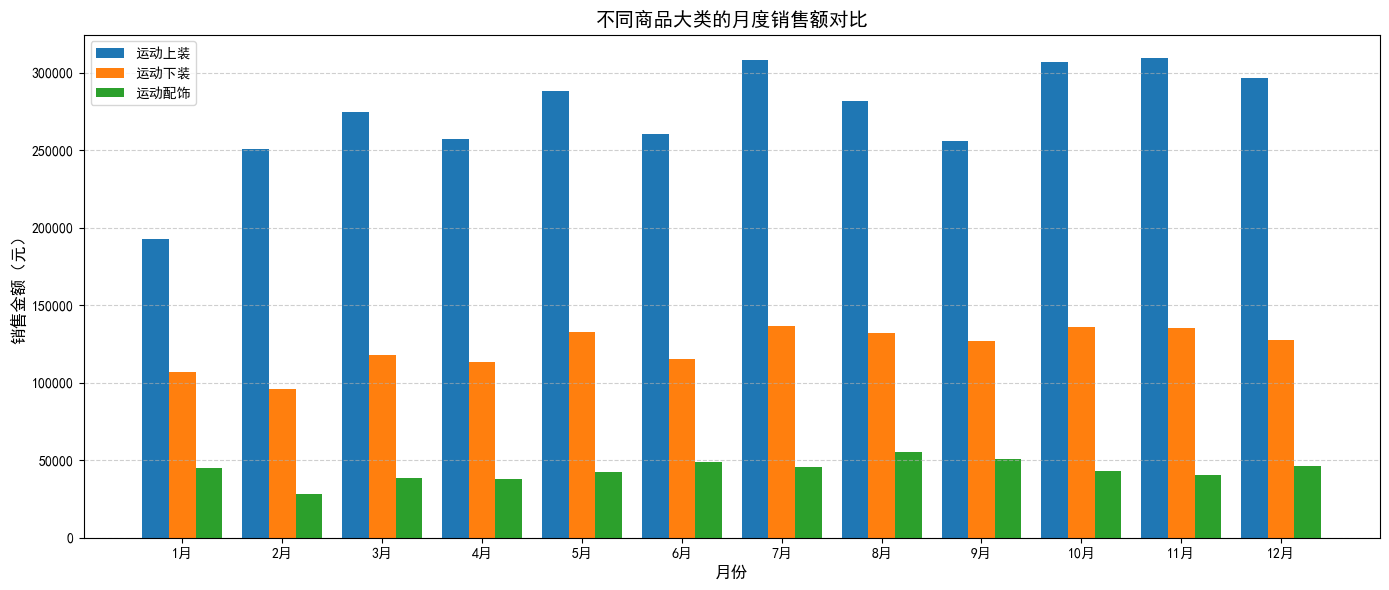

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 按【月份】和【商品大类】分组，汇总销售金额
category_monthly_sales = df.groupby(['月份', '商品大类'])['销售金额'].sum().reset_index()

# 2. 提取所有唯一的月份和商品大类
months = sorted(df['月份'].unique())  # 1-12月
categories = category_monthly_sales['商品大类'].unique()  # 所有商品大类

# 3. 为每个商品大类补全月份（缺失月份填0）
category_dfs = {}
for cat in categories:
    cat_df = category_monthly_sales[category_monthly_sales['商品大类'] == cat]
    cat_df = cat_df.set_index('月份').reindex(months, fill_value=0).reset_index()
    category_dfs[cat] = cat_df

# 4. 绘制柱状图
plt.figure(figsize=(14, 6))

# 柱子宽度和位置
n_categories = len(categories)
bar_width = 0.8 / n_categories  # 每个大类的柱子宽度

# 为每个商品大类绘制柱子
for i, cat in enumerate(categories):
    cat_df = category_dfs[cat]
    # 计算x位置：月份居中，大类间偏移
    x_pos = [m - 0.4 + (i + 0.5) * bar_width for m in months]
    # 绘制柱状图，并指定 label（用于图例）
    plt.bar(x_pos, cat_df['销售金额'], width=bar_width, label=cat)

# 5. 设置x轴刻度和标签
tick_positions = [m - 0.4 + n_categories * bar_width / 2 for m in months]
plt.xticks(tick_positions, [f'{m}月' for m in months])

# 6. 设置标题和坐标轴标签
plt.title('不同商品大类的月度销售额对比', fontsize=14)
plt.xlabel('月份', fontsize=12)
plt.ylabel('销售金额（元）', fontsize=12)

# 7. 添加图例（关键修复：直接传入 handles 和 labels）
plt.legend()

# 8. 添加网格线
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Part5 分析全年各商品小类的销售情况


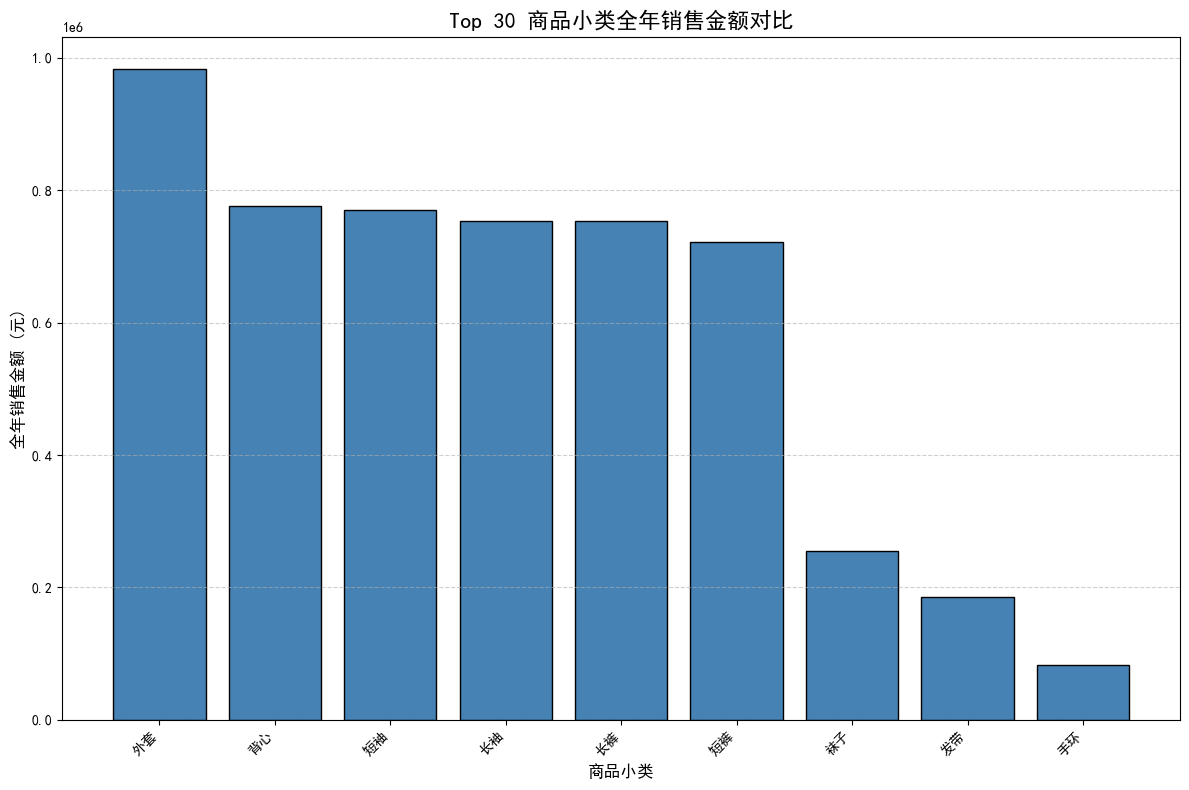

In [23]:
import matplotlib.pyplot as plt

# 设置中文字体，防止中文变成方块
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows系统用黑体
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号

# ==========================================
# 步骤 1 & 2：提取数据并计算全年总额
# ==========================================
# 按【商品小类】分组，对【销售金额】求和（这就得到了全年总销售额）
subcategory_sales = df.groupby('商品小类')['销售金额'].sum().reset_index()

# 为了方便看图，我们按销售额从高到低排序（Top 30）
subcategory_sales = subcategory_sales.sort_values(by='销售金额', ascending=False).head(30)

# ==========================================
# 步骤 3：绘制柱状图
# ==========================================
plt.figure(figsize=(12, 8))  # 设置画布大小，因为小类可能很多，所以高度给高一点

# 绘制柱状图
# x轴是商品小类名称，y轴是销售金额
plt.bar(subcategory_sales['商品小类'], subcategory_sales['销售金额'], color='steelblue', edgecolor='black')

# 设置标题和坐标轴标签（修正了原题中“y左边”的笔误）
plt.title('Top 30 商品小类全年销售金额对比', fontsize=16)
plt.xlabel('商品小类', fontsize=12)
plt.ylabel('全年销售金额 (元)', fontsize=12)

# 关键：旋转x轴标签，防止名字太长重叠在一起
plt.xticks(rotation=45, ha='right')

# 添加网格线，方便读取数值
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 紧凑布局并显示
plt.tight_layout()
plt.show()